# Midterm Project -- Red black Trees
### Group Members: 

In [ ]:
BLACK = 0
RED = 1
class node:
    def __init__(self, key, left = None, right = None, parent = None, color = RED):
        self.key = key
        self.p = parent
        self.left = left
        self.right = right
        self.color = color 

class RedBlackTree:
    """A Red-Black Tree like balancing binary search Tree"""
    def __init__(self):
        self.NIL = node(key = None, color = BLACK)
        self.NIL.left = None
        self.NIL.right = None
        self.root = self.NIL

    def search(self, x, k):
        if x == self.NIL or k == x.key:
            return x
        
        if k > x.key:
            return self.search(x.right, k)
        else:
            return self.search(x.left, k)
        
    def min(self, x):
        while x.left != self.NIL:
            x = x.left
        return x
    
    def max(self, x):
        while x.right != self.NIL:
            x = x.right
        return x
    
    def left_rotate(self, x):
        # Initialization
        y = x.right
        x.right = y.left

        # Connect y left child to x Connect y to x parent
        if y.left != self.NIL:
            y.left.p = x
        y.p = x.p
        
        # If x is root, set y to root, else y replace x place
        if x.p == self.NIL: 
            self.root = y
        elif x.p.left == x:
            x.p.left = y
        else:
            x.p.right = y
        
        # Reconnect x and y, y is parent
        y.left = x
        x.p = y

    def right_rotate(self, y):
        x = y.left
        y.left = x.right

        if x.right != self.NIL:
            x.right.p = y
        
        x.p = y.p
        if y.p == self.NIL:
            self.root = x
        elif y.p.left == y:
            y.p.left = x
        else:
            y.p.right = x
        
        x.right = y
        y.p = x

    def insert(self, key):
        # Create a new node
        z = node(key)
        # Find the place to insert z
        x = self.root
        y = self.NIL
        while x != self.NIL:
            # Save z's parent
            y = x
            if z.key < x.key:
                x = x.left
            else:
                x = x.right
        z.p = y

        # If there is no node in tree, z be the root
        if y == self.NIL: 
            self.root = z
        elif z.key < y.key:
            y.left = z
        else:
            y.right = z
        
        # Setting the z child to NIL
        z.left = self.NIL
        z.right = self.NIL

        self.insert_fixup(z)

    def insert_fixup(self, z):
        while z.p.color == RED:
            if z.p == z.p.p.left: 
                y = z.p.p.right # Check the uncle's color
                # Case 1, if uncle is RED, 
                if y.color == RED:
                    z.p.color = BLACK # Let parent and uncle be BLACK
                    y.color = BLACK
                    # Set grandparent to RED to maintain subtree's "Black height"
                    z.p.p.color = RED
                    z = z.p.p
                else:
                    # Case 2, z is right child
                    # Left rotate z and prepare for Case 3
                    if z == z.p.right:
                        z = z.p
                        self.left_rotate(z)
                    # Case 3, z is left child
                    # Maintain the subtree's height and Right rotate z grandparent 
                    z.p.color = BLACK
                    z.p.p.color = RED
                    self.right_rotate(z.p.p)
            else:
                y = z.p.p.left
                if y.color == RED:
                    z.p.color = BLACK
                    y.color = BLACK
                    z.p.p.color = RED
                    z = z.p.p
                else:
                    if z == z.p.left:
                        z = z.p
                        self.right_rotate(z)
                    z.p.color = BLACK
                    z.p.p.color = RED
                    self.left_rotate(z.p.p)
        self.root.color = BLACK

    def transplant (self, u, v):
        if u.p == self.NIL:
            self.root = v
        elif u == u.p.left:
            u.p.left = v
        else:
            u.p.right = v
    
        v.p = u.p
    
    def delete(self, z):
        y = z
        y_original_color = y.color
        # If 
        if z.left == self.NIL:
            x = z.right
            self.transplant(z, z.right) # Replace by right child
        elif z.right == self.NIL:
            x = z.left
            self.transplant(z, z.left) # Replace by left child
        else:
            y = self.min(z.right) # Find the successor node
            y_original_color = y.color
            # x is y's right child, which will replace y's original position.
            x = y.right
            if y!=z.right:
                # If y is deeper in the tree, replace y with x
                self.transplant(y, y.right)
                y.right = z.right
                y.right.p = y
            else:
                # If y is z's direct child, just update x's parent pointer (important if x is NIL)
                x.p = y
            # Replace z with y in the tree
            self.transplant(z, y)
            # Attach z's left subtree to y and inherit z's color
            y.left = z.left
            y.left.p = y
            y.color = z.color
        
        if y_original_color == BLACK:
            self.delete_fix(x)

def delete_fix(self, x):
    # Loop to push the "extra black" up the tree until we reach the root 
    # or a RED node that can absorb it.
    while x != self.root and x.color == BLACK:
        # --- x is a left child ---
        if x == x.p.left:
            w = x.p.right # w is x's sibling
            
            # Case 1: Sibling w is RED.
            # Strategy: Recolor and rotate to make the sibling BLACK (transforms to Case 2, 3, or 4).
            if w.color == RED:
                w.color = BLACK
                x.p.color = RED
                self.left_rotate(x.p)
                w = x.p.right
            
            # Case 2: Sibling w is BLACK, and both of w's children are BLACK.
            # Strategy: Strip black from w (make it RED), move the "extra black" up to x.p.
            if w.left.color == BLACK and w.right.color == BLACK:
                w.color = RED
                x = x.p
            else:
                # Case 3: Sibling w is BLACK, w.left is RED, w.right is BLACK.
                # Strategy: Recolor and rotate to transform into Case 4.
                if w.right.color == BLACK:
                    w.left.color = BLACK
                    w.color = RED
                    self.right_rotate(w)
                    w = x.p.right
                
                # Case 4: Sibling w is BLACK, and w.right is RED.
                # Strategy: Recolor and rotate to completely resolve the "extra black".
                w.color = x.p.color
                x.p.color = BLACK
                w.right.color = BLACK
                self.left_rotate(x.p)
                x = self.root # Set x to root to terminate the loop
                
        # --- x is a right child (Symmetric to the left child logic) ---
        else:
            w = x.p.left
            if w.color == RED:
                w.color = BLACK
                x.p.color = RED
                self.right_rotate(x.p)
                w = x.p.left
            
            if w.right.color == BLACK and w.left.color == BLACK:
                w.color = RED
                x = x.p
            else:
                if w.left.color == BLACK:
                    w.right.color = BLACK
                    w.color = RED
                    self.left_rotate(w)
                    w = x.p.left
                w.color = x.p.color
                x.p.color = BLACK
                w.left.color = BLACK
                self.right_rotate(x.p)
                x = self.root 
    x.color = BLACK


In [ ]:
import matplotlib.pyplot as plt

def get_coordinatesRB(T):

    def in_order(node, depth):
        nonlocal x, coords
        

        if node != T.NIL:
            in_order(node.left, depth+1)
            
            # coordinate data[node reference] = (in-order, depth, key, color, parent reference)
            coords[node] = (x, -depth, node.key, node.color, node.p)
            x += 1                                    # update count
            
            in_order(node.right, depth+1)
    
    x = 0              # initialize the count of nodes (x-coordinate)
    coords = {}        # data dictionary
    
    in_order(T.root, 0) # start the traversal to compute coordinates
    return coords

def PrintTreeRB(T, scale=0.75, node_size=2000, font=12):

    
    if T.root == T.NIL:
        print("Tree is empty.")
        return
        
    fig, ax = plt.subplots()            # create image (figure/axis) object
    coords = get_coordinatesRB(T)       # call recursive coordinate code
    
    if not coords:
        return
        
    b = 0.75 # outer border for image
    ax.set_xlim([-b, len(coords)])    # set the image frame (axis) limits
    ax.set_ylim([min([data[1] for hash_key,data in coords.items()])-b, b])
    
    for hash_key, data in coords.items():      
        x, y, key, color, parent = data
        text = str(key)
        

        c = "tomato" if color == RED else "dimgray"
        ec = "black"
        
        # Plot the point for the node
        ax.scatter([x], [y], s=node_size, zorder=2, color=c)
        
        # Add the annotation for the text of the nodes key
        ax.annotate(text, xy=(x,y), xytext=(x,y), 
                    fontsize=font, ha='center', va='center', zorder=3, color="white")
        
        # Add the lines for parent child-relationship
        if parent != T.NIL and parent is not None:
            px, py = coords[parent][0], coords[parent][1]
            ax.annotate("",
                    xy=(px,py), xytext=(x,y),
                    arrowprops=dict(arrowstyle="-", connectionstyle="arc3", color=ec)
                   ,zorder=1)
    
    plt.gcf().set_size_inches(16*scale, 9*scale)    # set figure size
    plt.axis('off')                                 
    plt.show()                                      # display the figure


========== 插入 15 个随机节点 测试 ==========


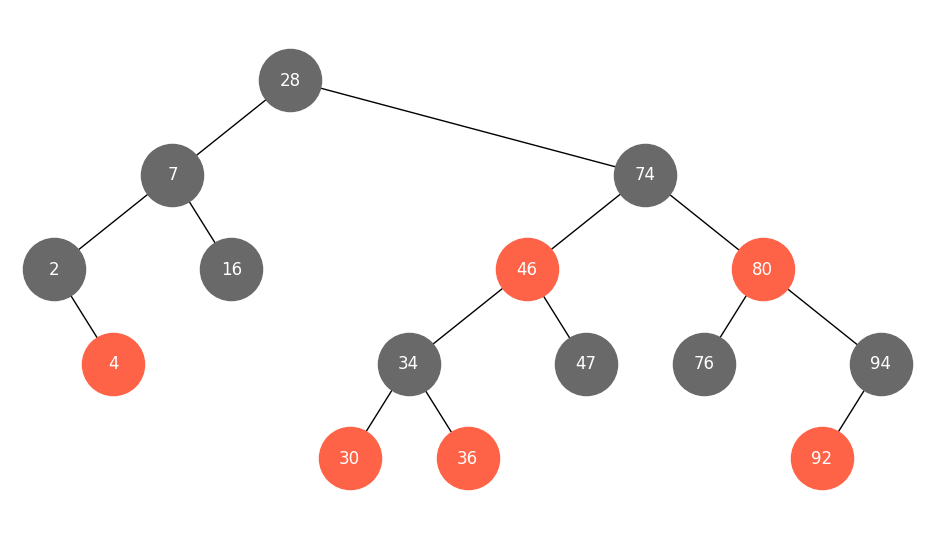

In [10]:
import random

n = 15

T = RedBlackTree()
KEYS = []

print(f"========== 插入 {n} 个随机节点 测试 ==========")
for i in range(n):
    key = random.randrange(99)
    KEYS.append(key)
    # print("inserting key =",key)
    T.insert(key)             # call insert

    
PrintTreeRB(T, node_size=2000)

KEYS = list(set(KEYS)) # 去除由于随机产生的重复插入的情况

deleting key = 4
-------------------------------------------------- DELETE DONE


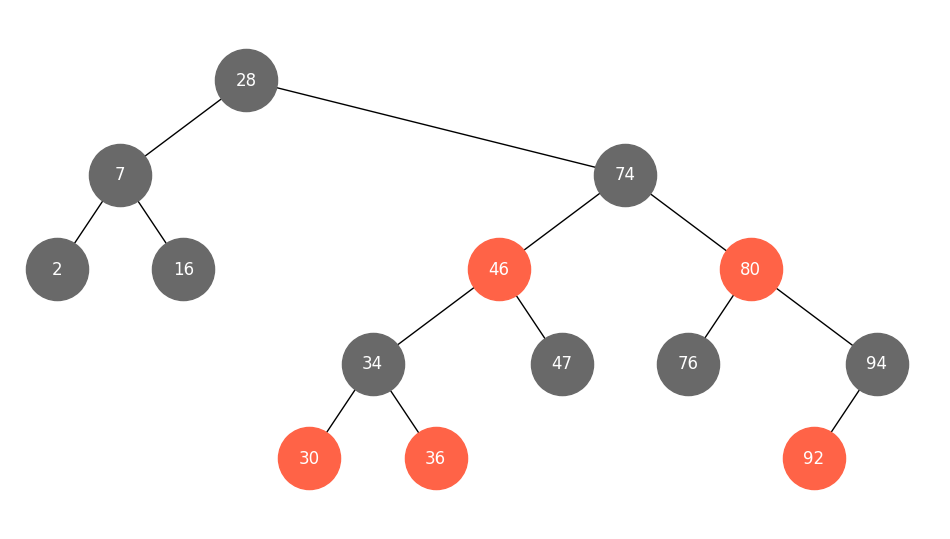

In [11]:
key = random.choice(KEYS)
print("deleting key =", key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-" * 50, "DELETE DONE")
PrintTreeRB(T, node_size=2000)

deleting key = 92
-------------------------------------------------- DELETE DONE


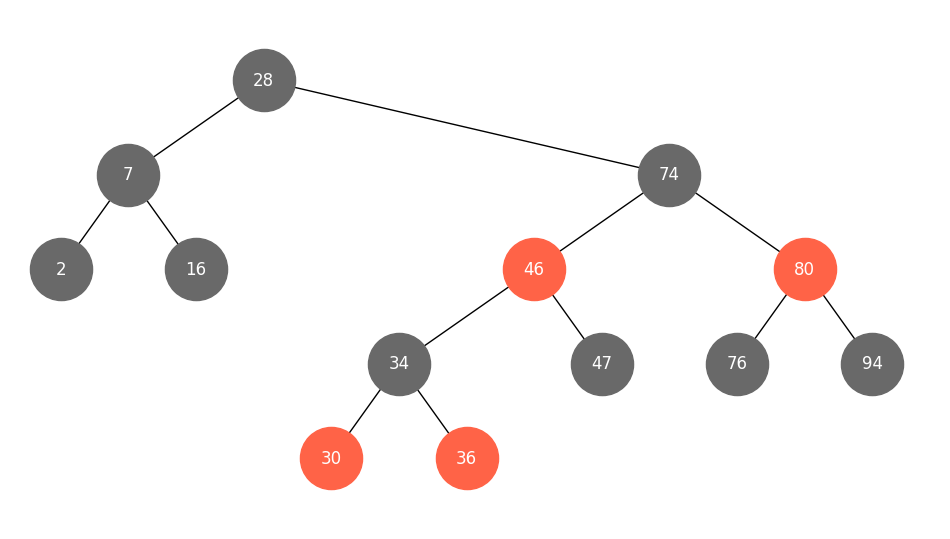

In [12]:
key = random.choice(KEYS)
print("deleting key =", key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-" * 50, "DELETE DONE")
PrintTreeRB(T, node_size=2000)

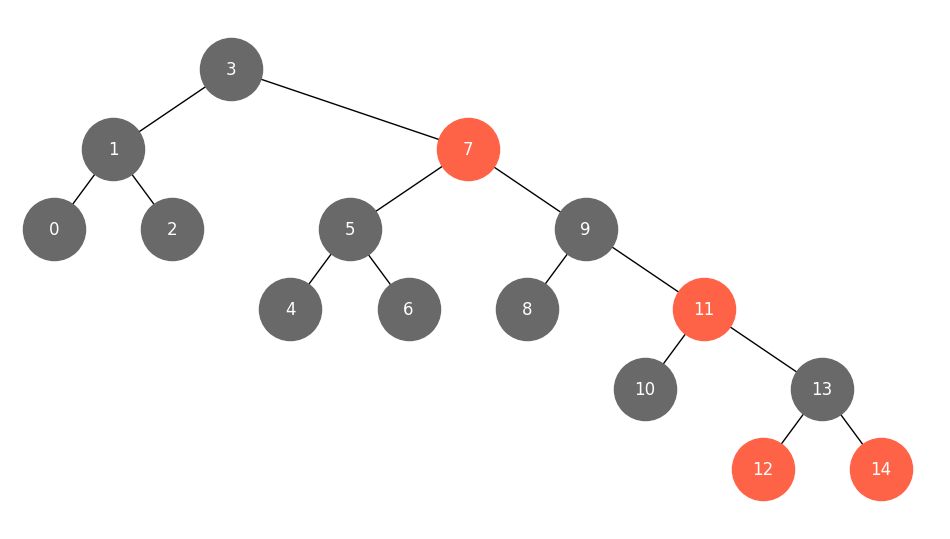

In [13]:
n = 15

T = RedBlackTree()

for i in range(n):
    #print("inserting key =",i)
    T.insert(i)             # call insert
    #print("-"*50,"INSERT DONE")
PrintTreeRB(T,node_size=2000)

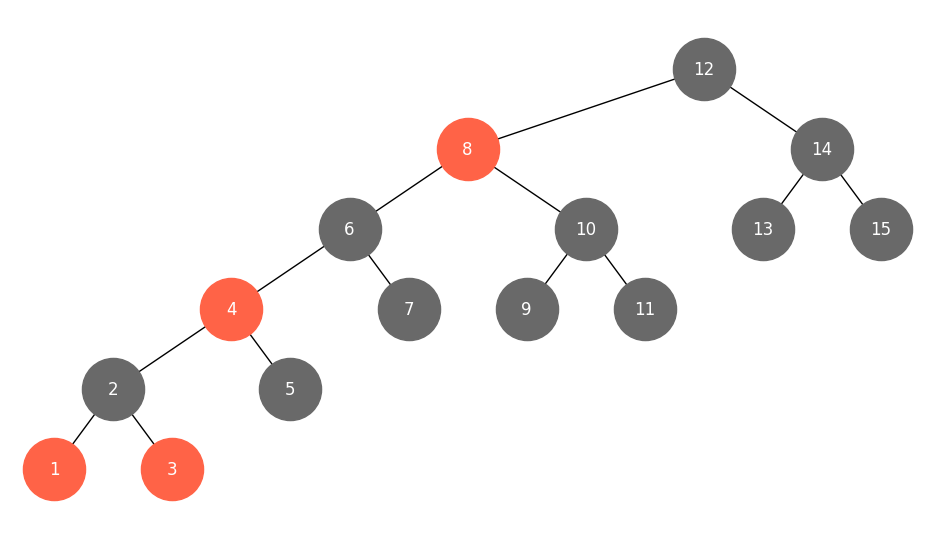

In [26]:
n = 15

T = RedBlackTree()

for i in range(n):
    #print("inserting key =",i)
    T.insert(n-i)             # call insert
    #print("-"*50,"INSERT DONE")
PrintTreeRB(T,node_size=2000)

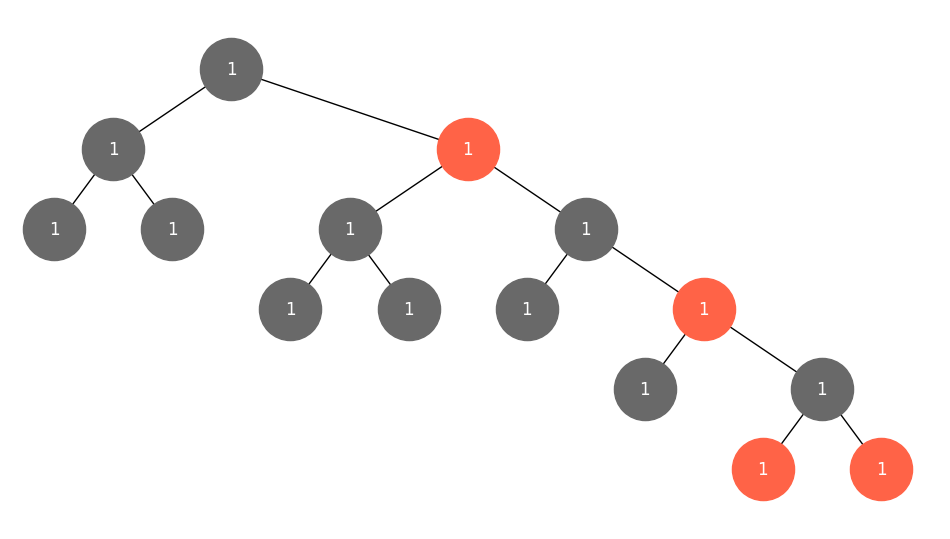

In [15]:
n = 15

T = RedBlackTree()

for i in range(n):
    #print("inserting key =",i)
    T.insert(1)             # call insert
    #print("-"*50,"INSERT DONE")
PrintTreeRB(T,node_size=2000)

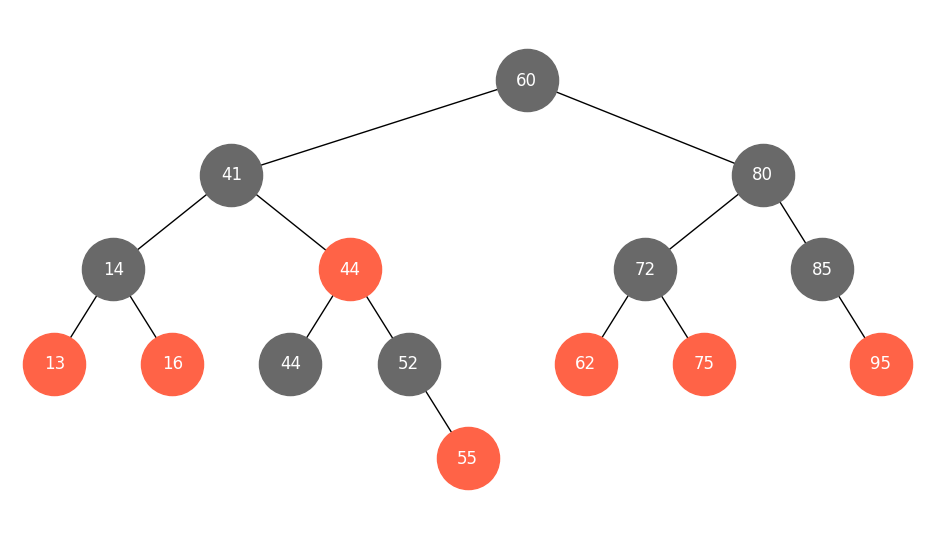

In [25]:
import random

n = 15

T = RedBlackTree()

for i in range(n):
    key = random.randrange(99)
    #print("inserting key =",key)
    T.insert(key)             # call insert
    #print("-"*50,"INSERT DONE")
PrintTreeRB(T,node_size=2000)

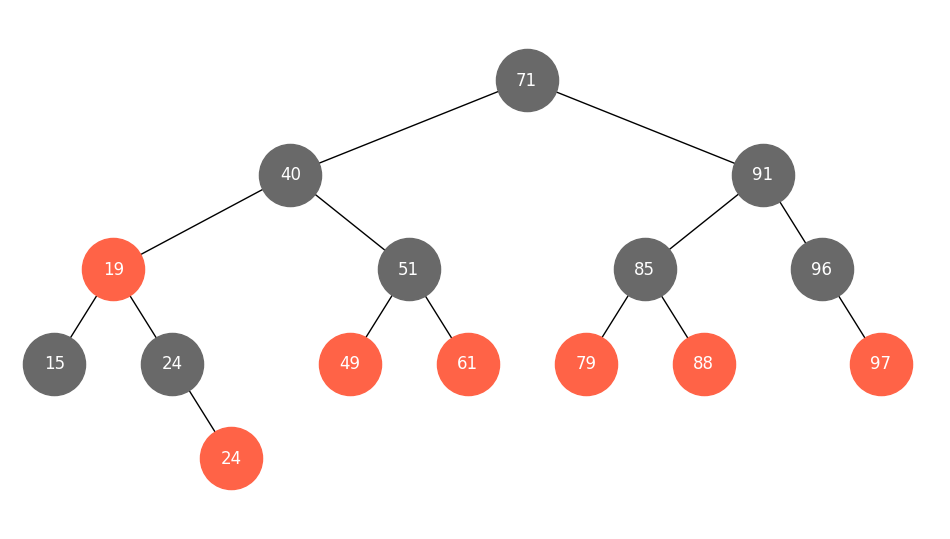

In [17]:
import random

n = 15

T = RedBlackTree()
KEYS = []

for i in range(n):
    key = random.randrange(99)
    KEYS.append(key)
    #print("inserting key =",key)
    T.insert(key)             # call insert
    #print("-"*50,"INSERT DONE")
PrintTreeRB(T,node_size=2000)
KEYS = list(set(KEYS))

deleting key = 19
-------------------------------------------------- DELETE DONE


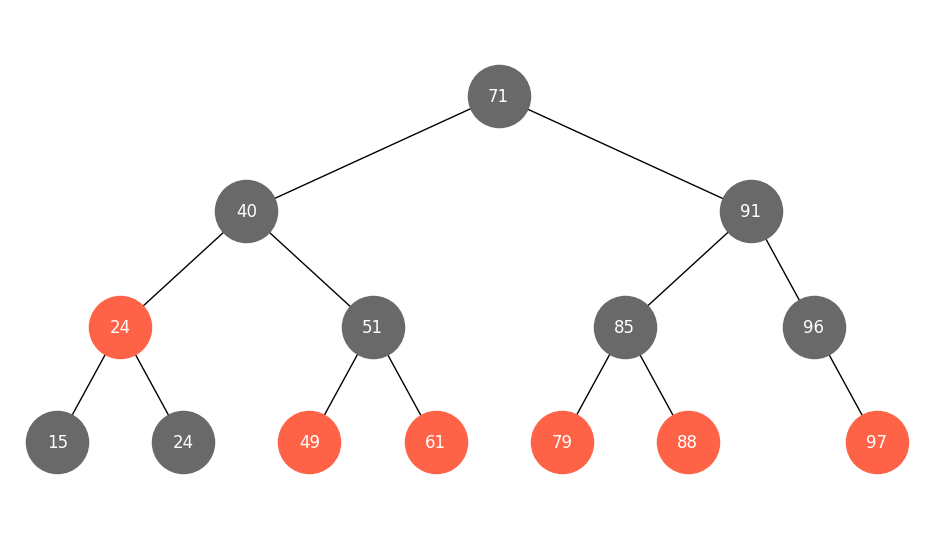

In [18]:
key = random.choice(KEYS)
print("deleting key =",key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-"*50,"DELETE DONE")
PrintTreeRB(T,node_size=2000)

deleting key = 71
-------------------------------------------------- DELETE DONE


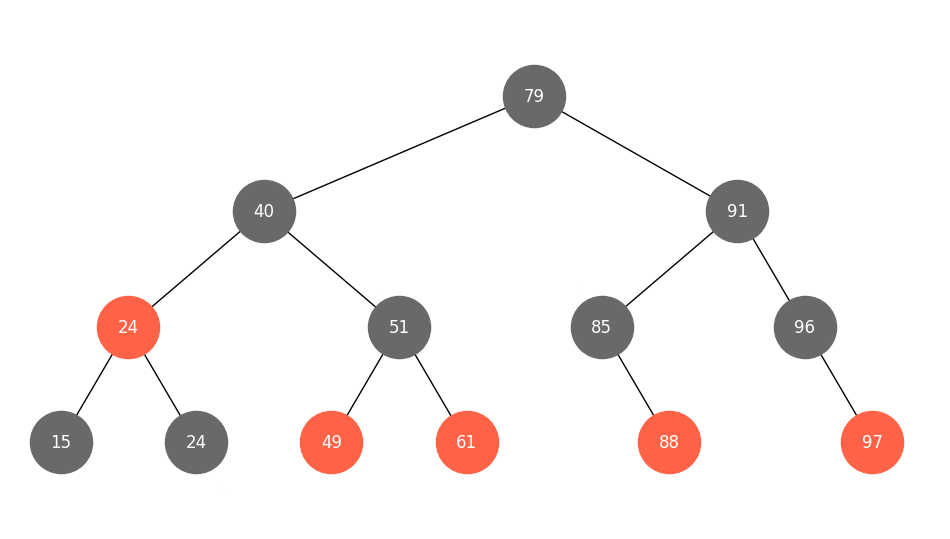

In [19]:
key = random.choice(KEYS)
print("deleting key =",key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-"*50,"DELETE DONE")
PrintTreeRB(T,node_size=2000)

deleting key = 97
-------------------------------------------------- DELETE DONE


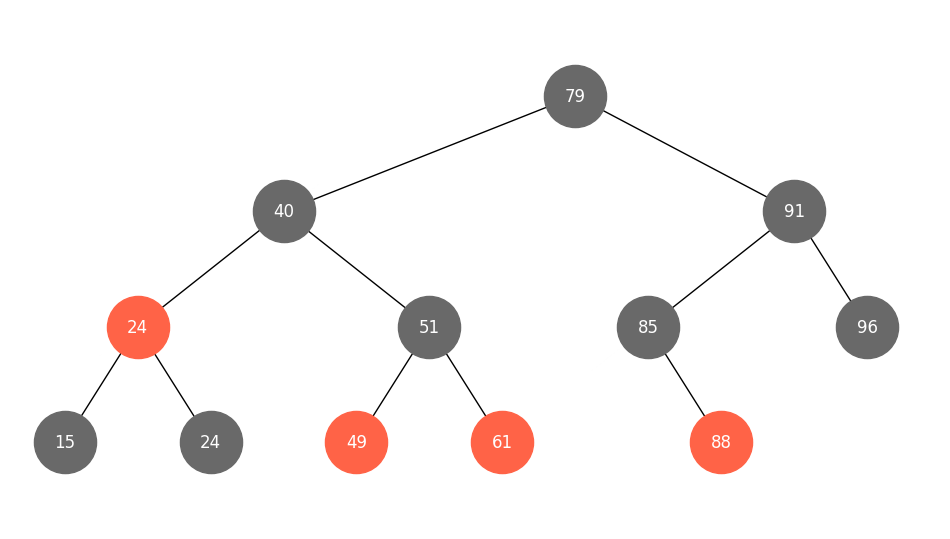

In [20]:
key = random.choice(KEYS)
print("deleting key =",key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-"*50,"DELETE DONE")
PrintTreeRB(T,node_size=2000)

deleting key = 40
-------------------------------------------------- DELETE DONE


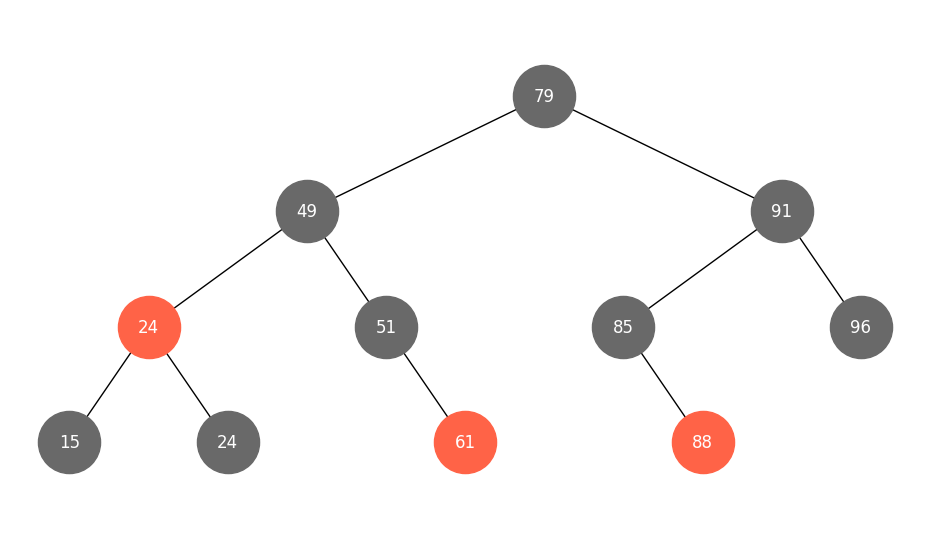

In [21]:
key = random.choice(KEYS)
print("deleting key =",key)
KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-"*50,"DELETE DONE")
PrintTreeRB(T,node_size=2000)

deleting key = 77
-------------------------------------------------- DELETE DONE


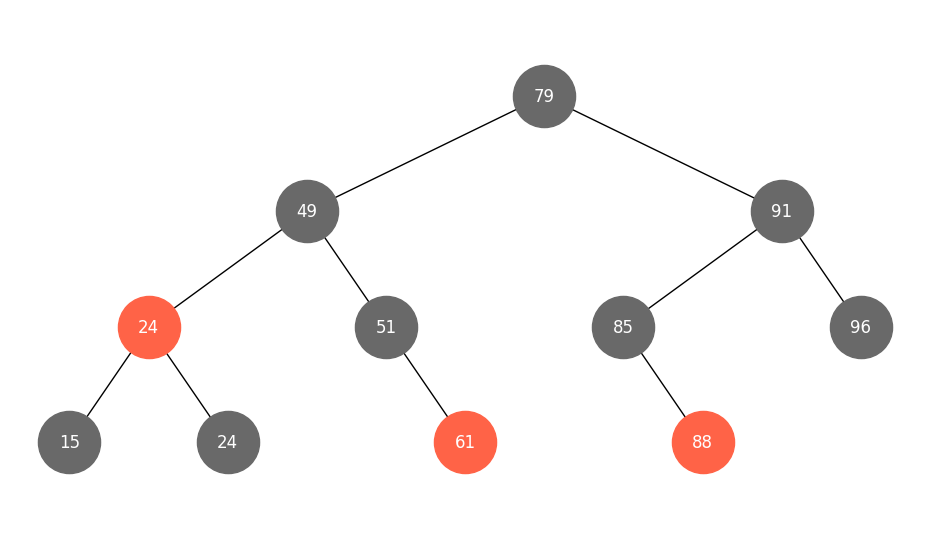

In [22]:
key = 77#random.choice(KEYS)
print("deleting key =",key)
#KEYS.remove(key)

# call the delete method
node_to_delete = T.search(T.root, key)
if node_to_delete != T.NIL:
    T.delete(node_to_delete)

print("-"*50,"DELETE DONE")
PrintTreeRB(T,node_size=2000)